# 🧠 Autism Detection — Full Pipeline
**Bharati Vidyapeeth's College of Engineering, New Delhi**

---
### Contents
1. [Imports & Dataset Loading](#section1)
2. [Preprocessing & EDA](#section2)
3. [Questionnaire ML Models (Logistic Regression + Random Forest)](#section3)
4. [Model Evaluation & Cross-Validation](#section4)
5. [Save Questionnaire Models](#section5)
6. [🆕 Video-Based ASD Detection (CNN Transfer Learning on SSBD)](#section6)
7. [🆕 Model Fusion — Combined Score](#section7)

## Section 1 — Imports & Dataset Loading

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [34]:
df = pd.read_csv('/content/drive/MyDrive/train (2).csv')
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


## Section 2 — Preprocessing & EDA

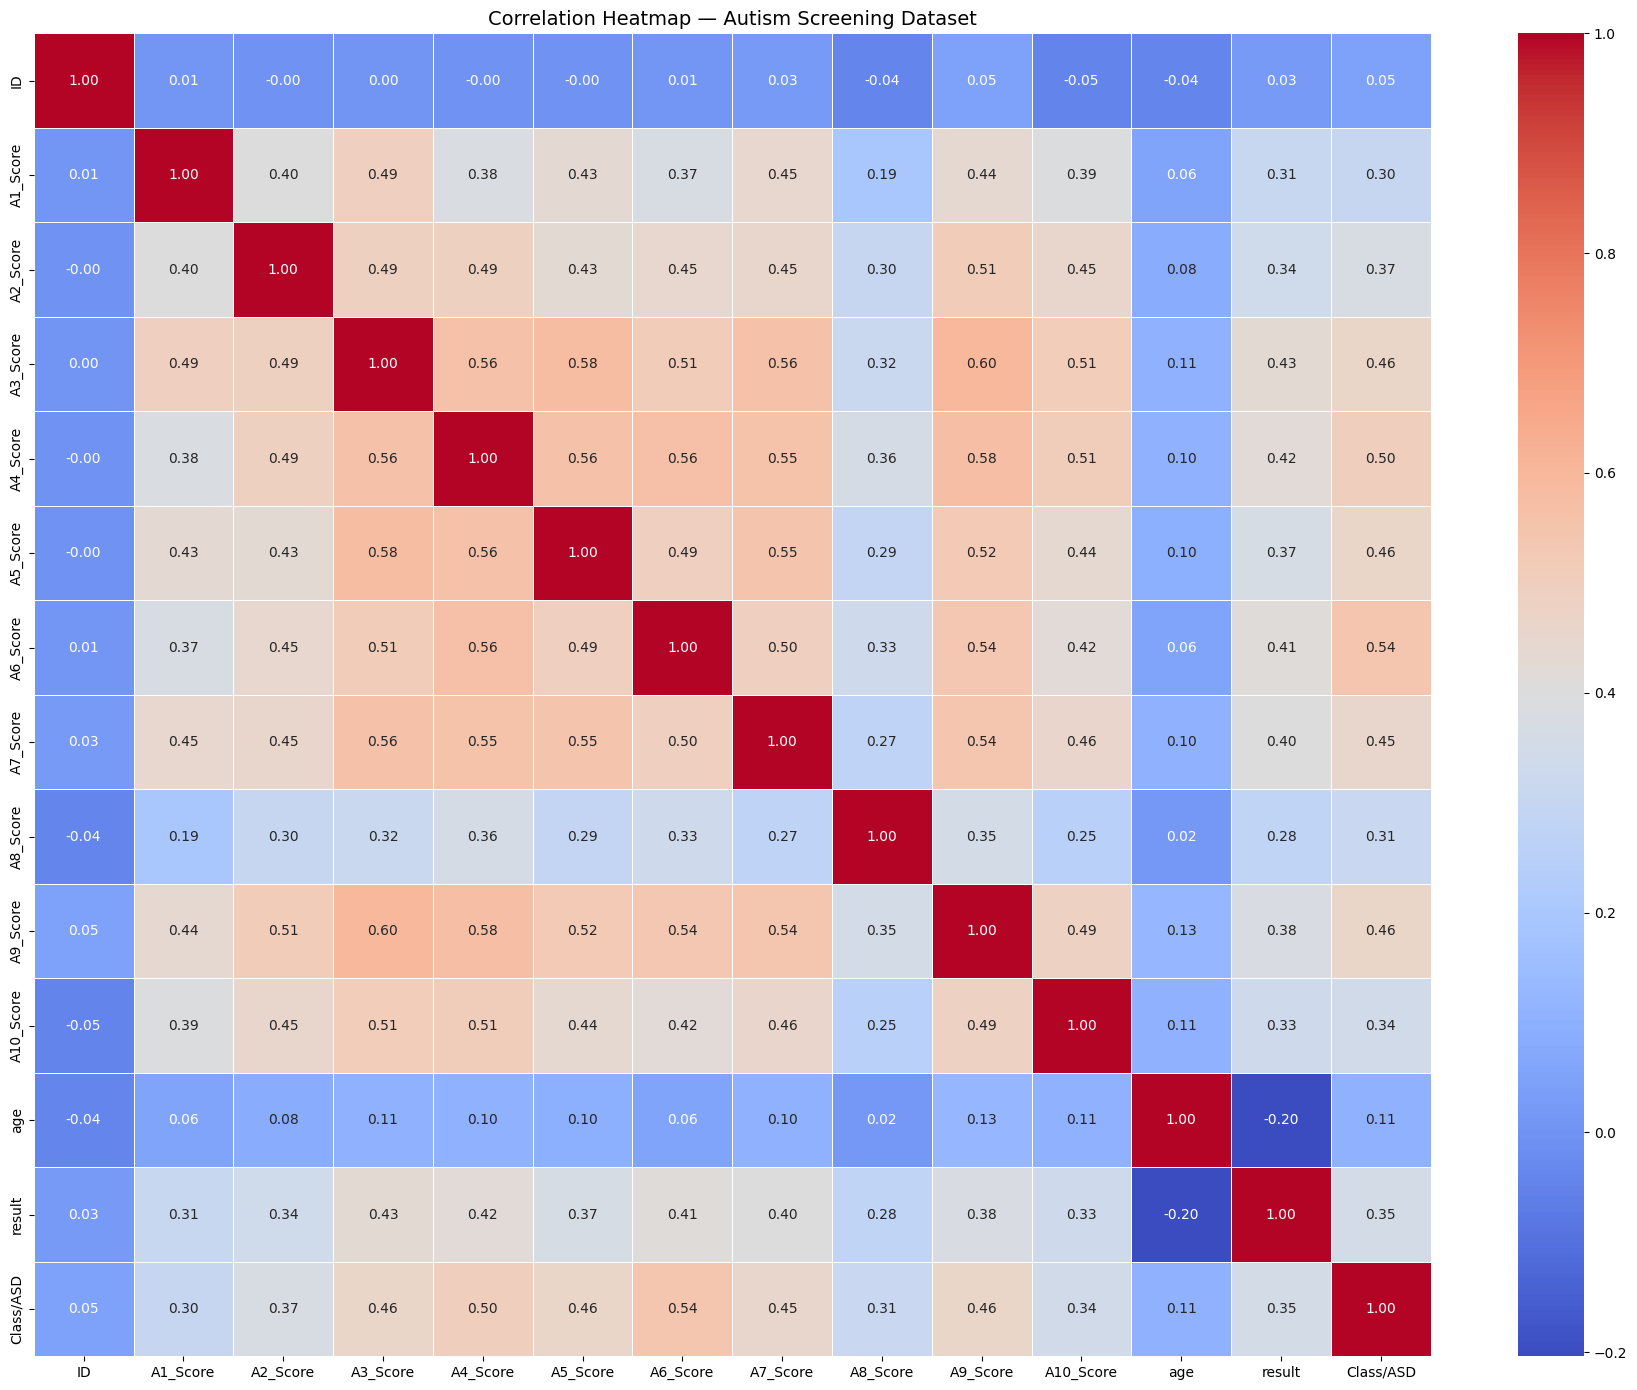

In [35]:
# Correlation Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Autism Screening Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Section 3 — Questionnaire ML Models

In [37]:
# Rename target column
df = df.rename(columns={'Class/ASD': 'target'})

# Drop unnecessary columns
df = df.drop(columns=['ID', 'result', 'age_desc', 'used_app_before'], errors='ignore')

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le_enc = LabelEncoder()

for col in ['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'relation']:
    if col in df.columns:
        df[col] = le_enc.fit_transform(df[col].astype(str))

# Feature engineering
df['total_A_score']    = df[['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                              'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']].sum(axis=1)
df['mean_A_score']     = df['total_A_score'] / 10
df['std_A_score']      = df[['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                              'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']].std(axis=1)
df['A_score_high_flag'] = (df['total_A_score'] >= 6).astype(int)

X = df.drop('target', axis=1)
y = df['target']

print("✅ Shape:", X.shape)
print("✅ Target distribution:\n", y.value_counts())

✅ Shape: (800, 21)
✅ Target distribution:
 target
0    639
1    161
Name: count, dtype: int64


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [40]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Logistic Regression')
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       124
           1       0.68      0.64      0.66        36

    accuracy                           0.85       160
   macro avg       0.79      0.78      0.78       160
weighted avg       0.85      0.85      0.85       160

ROC-AUC: 0.9070340501792115


In [41]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       124
           1       0.69      0.56      0.62        36

    accuracy                           0.84       160
   macro avg       0.78      0.74      0.76       160
weighted avg       0.84      0.84      0.84       160

ROC-AUC: 0.8907930107526881


## Section 4 — Cross-Validation

In [42]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_scores = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc')
print('Logistic Regression average ROC-AUC:', lr_scores.mean())

rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print('Random Forest average ROC-AUC:', rf_scores.mean())

Logistic Regression average ROC-AUC: 0.9059261219167561
Random Forest average ROC-AUC: 0.8943376152022189


## Section 5 — Save Questionnaire Models

In [43]:
import joblib
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Questionnaire models saved!')

Questionnaire models saved!


---
# 🆕 Section 6 — Video-Based ASD Detection

### Dataset: SSBD (Self-Stimulatory Behaviour Dataset)
- **75 videos** | 3 classes: `arm_flapping`, `headbanging`, `spinning`
- Download: https://rolandgoecke.net/research/datasets/ssbd/
- Curated version: https://github.com/Samwei1/autism-related-behavior

### Approach: MobileNetV2 Transfer Learning
- Extract **20 uniformly sampled frames** per video
- Feed each frame through **MobileNetV2** (pretrained on ImageNet, top frozen)
- **Average predictions** across all frames → final classification
- Trains in ~**15–25 min on Colab GPU** even with just 60 videos

### Folder structure required:
```
ssbd_videos/
  arm_flapping/   -> video1.mp4, video2.mp4 ...
  headbanging/    -> video1.mp4 ...
  spinning/       -> video1.mp4 ...
```

In [1]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.5 MB/s eta 0:00:00


In [2]:
import os

# All URLs from SSBD url_list.pdf
videos = {
    "arm_flapping": [
        "https://www.youtube.com/watch?v=I7fdv1q9-m8",
        "https://www.youtube.com/watch?v=hKf-IwHM6TI",
        "https://www.youtube.com/watch?v=Z2kfvB4lv7A",
        "https://www.youtube.com/watch?v=5Ps9iE8mPqY",
        "https://www.youtube.com/watch?v=pz1nIbRWb2M",
        "https://www.youtube.com/watch?v=nGoMpqcYcOg",
        "https://www.youtube.com/watch?v=5sgfS0SSh8o",
        "https://www.youtube.com/watch?v=JM8BHjJTSFM",
        "https://www.youtube.com/watch?v=1vRklwIBC28",
        "https://www.youtube.com/watch?v=MOt-6FAEP_g",
        "https://www.youtube.com/watch?v=AQ-jO6O5gow",
        "https://www.youtube.com/watch?v=UxpQpWzhOx0",
        "https://www.youtube.com/watch?v=AGmXuSY4gx0",
        "https://www.youtube.com/watch?v=I2rfPPinMHk",
        "https://www.youtube.com/watch?v=T9rbit_oiJA",
        "https://www.youtube.com/watch?v=WRGUUOZ5_wA",
        "https://www.youtube.com/watch?v=SOc13pnf-Dc",
        "https://www.youtube.com/watch?v=iDuAugAykcc",
        "https://www.youtube.com/watch?v=3Oh_Lmehb6c",
    ],
    "headbanging": [
        "https://www.youtube.com/watch?v=WRGUUOZ5_wA&t=67s",
        "https://www.youtube.com/watch?v=yCaymsrcNwA",
        "https://www.youtube.com/watch?v=a5BuwkqtIa0",
        "https://www.youtube.com/watch?v=k9MJ4pDQQ74",
        "https://www.youtube.com/watch?v=pzPhXbGEpSo",
        "https://www.youtube.com/watch?v=Lex0gIMd73g",
        "https://www.youtube.com/watch?v=WLtorzPESbc",
        "https://www.youtube.com/watch?v=aNaC46cUOJo",
        "https://www.youtube.com/watch?v=B9hYEIjsHDA",
        "https://www.youtube.com/watch?v=0Vk9itex_ds",
        "https://www.youtube.com/watch?v=TVMWW9SejgI",
        "https://www.youtube.com/watch?v=yMgx2lVjf5I",
        "https://www.youtube.com/watch?v=BUAFdqrw4fA",
        "https://www.youtube.com/watch?v=6sR-8llWl_s",
        "https://www.youtube.com/shorts/wxDzCOyhFXM",
        "https://www.youtube.com/watch?v=EE-p8Q7AW3Q",
        "https://www.youtube.com/watch?v=z7NeBs5wNOA",
    ],
    "spinning": [
        "https://www.youtube.com/watch?v=uNpUNkjNreg",
        "https://www.youtube.com/watch?v=sAgAvYT3D8s",
        "https://www.youtube.com/watch?v=Gt-WMpTP7IE",
        "https://www.youtube.com/watch?v=arn5UCMLlBo",
        "https://www.youtube.com/watch?v=2AS14wxMB-A",
        "https://www.youtube.com/watch?v=5MS6VZwZDi0",
        "https://www.youtube.com/watch?v=uWgI1w2fQhs",
        "https://www.youtube.com/watch?v=VAMZwnfAHyY",
        "https://www.youtube.com/watch?v=ZHJr17Q4384",
        "https://www.youtube.com/watch?v=gKED6S0eGYA",
        "https://www.youtube.com/watch?v=scM9g0LExJA",
        "https://www.youtube.com/watch?v=kFuxwAufWvQ",
        "https://www.youtube.com/watch?v=yiEo7Kg1ngY",
        "https://www.youtube.com/watch?v=8R1MfXoI3mo",
        "https://www.youtube.com/watch?v=U35q146wMZo",
        "https://www.youtube.com/shorts/gbwXCi4YizE",
        "https://www.youtube.com/watch?v=AXghcX_Bjac",
        "https://www.youtube.com/watch?v=Nxgk374ybVs",
        "https://www.youtube.com/watch?v=WHG4dXC8BfI",
    ]
}

# Download all videos
BASE_DIR = "/content/ssbd_videos"
failed = []

for label, urls in videos.items():
    save_dir = os.path.join(BASE_DIR, label)
    os.makedirs(save_dir, exist_ok=True)
    print(f"\n📥 Downloading {label} ({len(urls)} videos)...")

    for i, url in enumerate(urls):
        out_template = os.path.join(save_dir, f"{label}_{i+1:02d}.%(ext)s")
        cmd = (
            f'yt-dlp -f "mp4/bestvideo[ext=mp4]" '
            f'--output "{out_template}" '
            f'--no-playlist '
            f'--quiet '
            f'"{url}"'
        )
        ret = os.system(cmd)
        if ret != 0:
            print(f"  ⚠️  Failed: {url}")
            failed.append((label, url))
        else:
            print(f"  ✅ {label}_{i+1:02d}")

print(f"\n\n=== Download Complete ===")
print(f"Failed: {len(failed)}")
for lbl, u in failed:
    print(f"  {lbl}: {u}")


📥 Downloading arm_flapping (19 videos)...
  ✅ arm_flapping_01
  ✅ arm_flapping_02
  ✅ arm_flapping_03
  ✅ arm_flapping_04
  ✅ arm_flapping_05
  ✅ arm_flapping_06
  ✅ arm_flapping_07
  ✅ arm_flapping_08
  ✅ arm_flapping_09
  ✅ arm_flapping_10
  ✅ arm_flapping_11
  ✅ arm_flapping_12
  ✅ arm_flapping_13
  ✅ arm_flapping_14
  ⚠️  Failed: https://www.youtube.com/watch?v=T9rbit_oiJA
  ⚠️  Failed: https://www.youtube.com/watch?v=WRGUUOZ5_wA
  ✅ arm_flapping_17
  ✅ arm_flapping_18
  ✅ arm_flapping_19

📥 Downloading headbanging (17 videos)...
  ⚠️  Failed: https://www.youtube.com/watch?v=WRGUUOZ5_wA&t=67s
  ✅ headbanging_02
  ✅ headbanging_03
  ✅ headbanging_04
  ⚠️  Failed: https://www.youtube.com/watch?v=pzPhXbGEpSo
  ✅ headbanging_06
  ✅ headbanging_07
  ✅ headbanging_08
  ✅ headbanging_09
  ✅ headbanging_10
  ✅ headbanging_11
  ✅ headbanging_12
  ✅ headbanging_13
  ✅ headbanging_14
  ⚠️  Failed: https://www.youtube.com/shorts/wxDzCOyhFXM
  ✅ headbanging_16
  ✅ headbanging_17

📥 Downloading

In [3]:
for label in ["arm_flapping", "headbanging", "spinning"]:
    path = f"/content/ssbd_videos/{label}"
    files = [f for f in os.listdir(path) if f.endswith(".mp4")]
    print(f"{label}: {len(files)} videos")

arm_flapping: 17 videos
headbanging: 14 videos
spinning: 18 videos


In [4]:
# Install opencv if not already available
!pip install -q opencv-python-headless

In [5]:
import cv2
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
# ─────────────────────────────────────────
# STEP 1: Frame Extraction Utility
# ─────────────────────────────────────────

def extract_frames(video_path, n_frames=20, img_size=224):
    """
    Uniformly sample n_frames from a video.
    Returns: numpy array of shape (n_frames, img_size, img_size, 3) or None
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'  [WARN] Cannot open: {video_path}')
        return None

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 5:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) < 5:
        return None
    return np.array(frames, dtype=np.float32)

In [23]:
# ─────────────────────────────────────────
# STEP 2: Build Dataset
# Each video → mean frame (224,224,3)
# ─────────────────────────────────────────

import cv2
import os
import numpy as np

def build_video_dataset(data_dir, n_frames=20, img_size=224):
    X, y = [], []
    classes = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    print(f'Classes found: {classes}')

    for label in classes:
        class_dir = os.path.join(data_dir, label)
        video_files = [
            f for f in os.listdir(class_dir)
            if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))
        ]
        print(f'  {label}: {len(video_files)} videos')

        for fname in video_files:
            vpath  = os.path.join(class_dir, fname)
            frames = extract_frames(vpath, n_frames, img_size)
            if frames is None:
                continue
            # ✅ FIX: multiple frames per video instead of mean
            for frame in frames[::4]:   # every 4th frame ~5 samples per video
                X.append(frame)
                y.append(label)

    print(f'\nTotal samples loaded: {len(X)}')
    return np.array(X, dtype=np.float32), np.array(y)

In [24]:
# ─────────────────────────────────────────
# STEP 3: Build MobileNetV2 Transfer Learning Model
# ─────────────────────────────────────────

def build_video_model(num_classes, learning_rate=1e-4):
    """
    MobileNetV2 backbone (frozen) + custom head for ASD behavior classification.
    Very fast to train — only the head is trained.
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    # Freeze all base layers
    base_model.trainable = False

    # Custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'Model built. Trainable params: {model.count_params():,}')
    return model, base_model

In [31]:

# ─────────────────────────────────────────
# STEP 4: Load SSBD Dataset & Train
# ─────────────────────────────────────────
DATA_DIR = '/content/ssbd_videos'
X_video, y_video = build_video_dataset(DATA_DIR, n_frames=20)

# Normalize pixels to [0, 1]
X_video = X_video / 255.0

# Encode string labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_video)
y_cat     = tf.keras.utils.to_categorical(y_encoded)

print('Classes:', le.classes_)
print('X shape:', X_video.shape, '| y shape:', y_cat.shape)

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_video, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}')

Classes found: ['arm_flapping', 'headbanging', 'spinning']
  arm_flapping: 17 videos
  headbanging: 14 videos
  spinning: 18 videos

Total samples loaded: 245
Classes: ['arm_flapping' 'headbanging' 'spinning']
X shape: (245, 224, 224, 3) | y shape: (245, 3)
Train: 196 | Test: 49


In [26]:
# ─────────────────────────────────────────
# STEP 5: Train Phase 1 — Frozen backbone
# ─────────────────────────────────────────

num_classes = len(le.classes_)
video_model, base_model = build_video_model(num_classes)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

print('\n── Phase 1: Training classification head (backbone frozen) ──')
history1 = video_model.fit(
    X_tr, y_tr,
    epochs=25,
    batch_size=16,
    validation_data=(X_te, y_te),
    callbacks=callbacks,
    verbose=1
)

Model built. Trainable params: 2,624,323

── Phase 1: Training classification head (backbone frozen) ──
Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.3622 - loss: 1.5747 - val_accuracy: 0.3469 - val_loss: 1.2218 - learning_rate: 1.0000e-04
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4235 - loss: 1.3645 - val_accuracy: 0.4898 - val_loss: 1.0849 - learning_rate: 1.0000e-04
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5102 - loss: 1.1491 - val_accuracy: 0.5510 - val_loss: 1.0187 - learning_rate: 1.0000e-04
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5357 - loss: 0.9916 - val_accuracy: 0.6122 - val_loss: 0.9696 - learning_rate: 1.0000e-04
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5204 - loss: 0.9753 - val_accuracy: 0.6122 - val_loss: 0.9312 - learning_rate: 1.0000e-04
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6173 - loss: 0.8520 - val_accuracy: 0.6327 - val_loss: 0.

In [27]:
# ─────────────────────────────────────────
# STEP 6: Fine-tune — Unfreeze last 20 layers
# (Optional but improves accuracy ~3-5%)
# ─────────────────────────────────────────

print('\n── Phase 2: Fine-tuning last 20 layers of MobileNetV2 ──')
for layer in base_model.layers[-20:]:
    layer.trainable = True

video_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = video_model.fit(
    X_tr, y_tr,
    epochs=15,
    batch_size=8,
    validation_data=(X_te, y_te),
    callbacks=callbacks,
    verbose=1
)


── Phase 2: Fine-tuning last 20 layers of MobileNetV2 ──
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 677ms/step - accuracy: 0.7602 - loss: 0.6289 - val_accuracy: 0.8776 - val_loss: 0.4803 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7755 - loss: 0.6144 - val_accuracy: 0.8776 - val_loss: 0.4906 - learning_rate: 1.0000e-05
Epoch 3/15
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7937 - loss: 0.5141
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8112 - loss: 0.5076 - val_accuracy: 0.8163 - val_loss: 0.5019 - learning_rate: 1.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8418 - loss: 0.4404 - val_accuracy: 0.8163 - val_loss: 0.5168 - learning_rate: 5.0000e-06
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8112 - loss: 0.4406 - val_accuracy: 0.8163 - val_loss: 0.5269 - learning_rate: 5.0000e-06
Epoch 5: early 

2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step

── Video Model Evaluation ──
              precision    recall  f1-score   support

arm_flapping       0.88      0.82      0.85        17
 headbanging       0.81      0.93      0.87        14
    spinning       0.94      0.89      0.91        18

    accuracy                           0.88        49
   macro avg       0.88      0.88      0.88        49
weighted avg       0.88      0.88      0.88        49



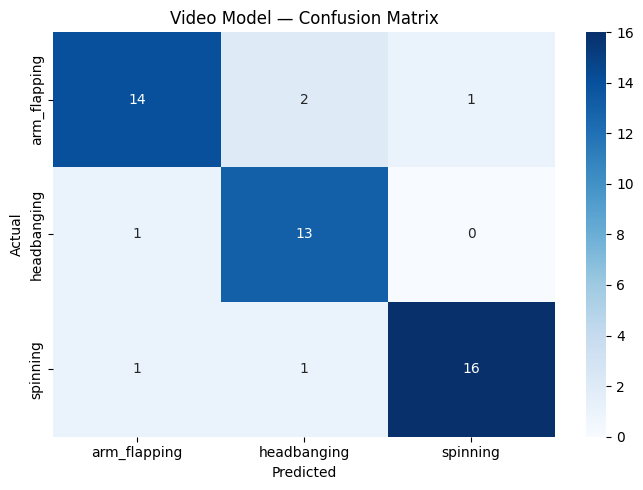

In [28]:
# ─────────────────────────────────────────
# STEP 7: Evaluation
# ─────────────────────────────────────────

y_pred_prob = video_model.predict(X_te)
y_pred_cls  = np.argmax(y_pred_prob, axis=1)
y_true_cls  = np.argmax(y_te, axis=1)

print('\n── Video Model Evaluation ──')
print(classification_report(y_true_cls, y_pred_cls, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Video Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('video_confusion_matrix.png', dpi=150)
plt.show()

In [30]:
# ─────────────────────────────────────────
# STEP 8: Save Video Model
# ─────────────────────────────────────────

video_model.save('video_model.h5')
joblib.dump(le, 'video_label_encoder.pkl')
print('video_model.h5 saved!')
print('video_label_encoder.pkl saved!')
print('Classes:', list(le.classes_))

video_model.h5 saved!
video_label_encoder.pkl saved!
Classes: [np.str_('arm_flapping'), np.str_('headbanging'), np.str_('spinning')]


---
# 🆕 Section 7 — Model Fusion (Questionnaire + Video)

Combine the questionnaire ASD risk score with video behavior detection for a **unified prediction**.
This mirrors the multimodal approach from the MMASD research papers cited in your review.

In [44]:
# ─────────────────────────────────────────
# Fusion: Weighted average of questionnaire
# probability + video confidence
# ─────────────────────────────────────────

def fused_prediction(
    questionnaire_features,
    video_path,
    rf_model,
    scaler,
    video_model,
    label_encoder,
    q_weight=0.6,
    v_weight=0.4
):
    """
    Combine questionnaire + video predictions.

    Parameters:
        questionnaire_features: list of 24 features (same as app.py)
        video_path:             path to video file
        q_weight / v_weight:    weight of each modality (must sum to 1)

    Returns dict with final prediction and component scores.
    """
    # ── Questionnaire Score ──
    feat_scaled   = scaler.transform([questionnaire_features])
    q_prob_asd    = rf_model.predict_proba(feat_scaled)[0][1]  # P(ASD)

    # ── Video Score ──
    frames = extract_frames(video_path, n_frames=20)
    stimming_classes = ['arm_flapping', 'headbanging', 'spinning']

    if frames is not None:
        frames_norm  = frames / 255.0
        preds        = video_model.predict(frames_norm, verbose=0)
        avg_probs    = preds.mean(axis=0)
        pred_label   = label_encoder.inverse_transform([np.argmax(avg_probs)])[0]

        # Sum probabilities of stimming behaviors as video ASD score
        stimming_indices = [
            i for i, c in enumerate(label_encoder.classes_)
            if c in stimming_classes
        ]
        v_prob_asd = avg_probs[stimming_indices].sum()
    else:
        pred_label = 'unavailable'
        v_prob_asd = 0.0
        # Fall back to questionnaire only
        q_weight, v_weight = 1.0, 0.0

    # ── Fused Score ──
    fused_score = q_weight * q_prob_asd + v_weight * v_prob_asd
    final_pred  = 1 if fused_score >= 0.5 else 0

    return {
        'questionnaire_asd_prob' : round(float(q_prob_asd), 4),
        'video_asd_prob'         : round(float(v_prob_asd), 4),
        'fused_score'            : round(float(fused_score), 4),
        'final_prediction'       : final_pred,
        'video_detected_behavior': pred_label
    }


# ── Quick demo (no actual video needed) ──
print('Fusion function defined.')
print('Usage: fused_prediction(features, video_path, rf, scaler, video_model, le)')

Fusion function defined.
Usage: fused_prediction(features, video_path, rf, scaler, video_model, le)


In [45]:
# ─────────────────────────────────────────
# Summary — All saved files
# ─────────────────────────────────────────

saved_files = ['rf_model.pkl', 'scaler.pkl', 'video_model.h5', 'video_label_encoder.pkl']
print('\n=== Files to copy to your Streamlit app directory ===')
for f in saved_files:
    exists = os.path.exists(f)
    print(f'  {"✅" if exists else "❌"} {f}')


=== Files to copy to your Streamlit app directory ===
  ✅ rf_model.pkl
  ✅ scaler.pkl
  ✅ video_model.h5
  ✅ video_label_encoder.pkl


In [47]:
from google.colab import files
files.download('/content/ssbd_videos/arm_flapping/arm_flapping_01.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import cv2
import numpy as np

out = cv2.VideoWriter(
    'test_video.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    15, (224, 224)
)

for i in range(60):
    # White background
    frame = np.ones((224, 224, 3), dtype=np.uint8) * 255

    # Moving circle (simulates motion)
    x = int(112 + 80 * np.sin(i * 0.2))
    y = int(112 + 80 * np.cos(i * 0.2))
    cv2.circle(frame, (x, y), 20, (255, 0, 0), -1)

    # Add text
    cv2.putText(frame, f'Frame {i}', (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    out.write(frame)

out.release()
print("✅ Video created!")

from google.colab import files
files.download('test_video.mp4')

✅ Video created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>